In [1]:
import pandas as pd
from matplotlib import pyplot as plt

from xaikd import models, utils

from functools import lru_cache
import numpy as np

In [2]:
@lru_cache()
def count_params(model_name):
    model = models.get_trained_model(model_name)
    return utils.count_params_in_model(model)

count_params("imagenet-vgg16-tv")

(138357544, 138357544)

In [3]:
def load_data(model_name, arr_layers):
    arr_dfs = []
    for layer in arr_layers:
        df = pd.read_csv(f"../../artifacts/2024-11-ipam-subspace/experiments/accuracy-basis/imagenet/{model_name}/{layer}/pca--uncentered/accuracy.csv")
        df["layer"] = layer
        arr_dfs.append(df)
    df = pd.concat(arr_dfs)
    
    return df
load_data("imagenet-resnet18-tv", ["layer1", "layer2"])

,k,original_loss,original_accuracy,train_loss,train_acc,val_loss,val_acc,layer
0,32,1.246912,0.6976,0.894075,0.769136,1.320710,0.67980,layer1
1,40,1.246912,0.6976,0.839553,0.781537,1.280271,0.68946,layer1
2,48,1.246912,0.6976,0.808232,0.789155,1.258176,0.69428,layer1
3,56,1.246912,0.6976,0.796237,0.791950,1.250473,0.69620,layer1
4,64,1.246912,0.6976,0.790657,0.793254,1.246922,0.69754,layer1
0,64,1.246912,0.6976,0.943598,0.756539,1.363961,0.67082,layer2
1,80,1.246912,0.6976,0.860796,0.776917,1.297051,0.68404,layer2
2,96,1.246912,0.6976,0.821274,0.785858,1.267413,0.69222,layer2
3,112,1.246912,0.6976,0.802070,0.790540,1.254319,0.69474,layer2
4,128,1.246912,0.6976,0.790651,0.793242,1.246903,0.69760,layer2


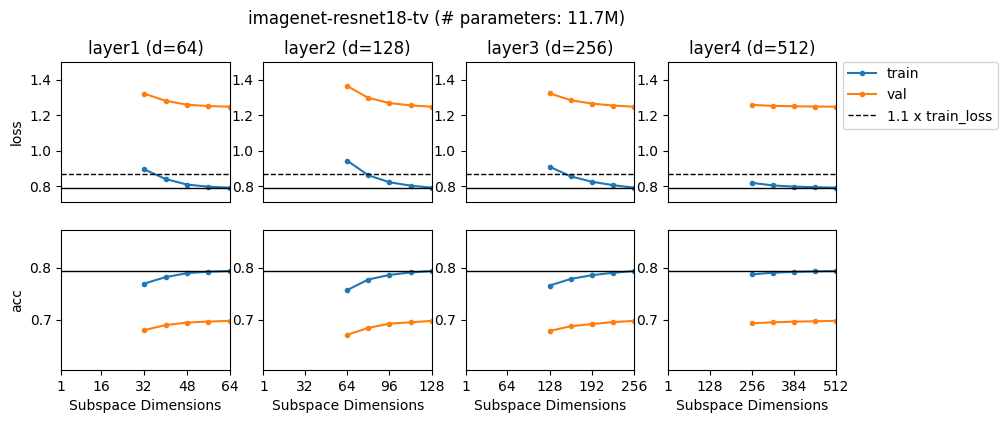

In [4]:
def viz(model_name, arr_layers):

    ncols = len(arr_layers)

    arr_columns = ["loss", "acc"]
    nrows = len(arr_columns)

    _, trainable_params = count_params(model_name)
    
    plt.figure(figsize=(2.5*ncols, 2 * nrows))
    plt.suptitle(f"{model_name} (# parameters: {trainable_params/1e6:.1f}M)", y=1.01)
    
    df = load_data(model_name, arr_layers)

    for lix, layer in enumerate(arr_layers):
        _df = df[df.layer == layer]
        layer_dimensions = _df.k.max()
        for cix, col in enumerate(arr_columns):
            plt.subplot(nrows, ncols, cix * ncols + lix + 1)
            plt.xlim([1, layer_dimensions])

            plt.xticks([1, layer_dimensions // 4, layer_dimensions // 2, layer_dimensions * 3 // 4, layer_dimensions])
            for data_label in ["train", "val"]:
                col_slug = f"{data_label}_{col}"
                plt.plot(
                    _df.k, 
                    _df[col_slug],
                    marker=".",
                    label=data_label
                )

            ref_value = _df[f"train_{col}"].values[-1]
            plt.axhline(ref_value, ls="-", lw=1, color="k")
            if col == "loss":
                for ls, factor in [("--", 1.1)]:
                    plt.axhline(ref_value*factor, ls=ls, lw=1, color="k", label=f"{factor} x train_loss")


            if cix == 0 and lix == ncols - 1:
                plt.legend(loc="upper right", bbox_to_anchor=(2, 1.05))
                
            if cix == 0:
                layer_name = layer.replace("encoder.", "")
                plt.title(f"{layer_name} (d={layer_dimensions})")
                plt.xticks([])
            else:
                plt.xlabel("Subspace Dimensions")
        
            if col == "acc":
                plt.ylim([
                    df.val_acc.min() * 0.9,
                    df.train_acc.max() * 1.1
                ])
            else:
                pass
                plt.ylim([
                    df.train_loss.min() * 0.9,
                    df.val_loss.max() * 1.1,
                ])
            if lix == 0:
                plt.ylabel(col)
            # else:
            #     plt.yticks([])
            

viz(
    model_name="imagenet-resnet18-tv",
    arr_layers=["layer1", "layer2", "layer3", "layer4"]
)

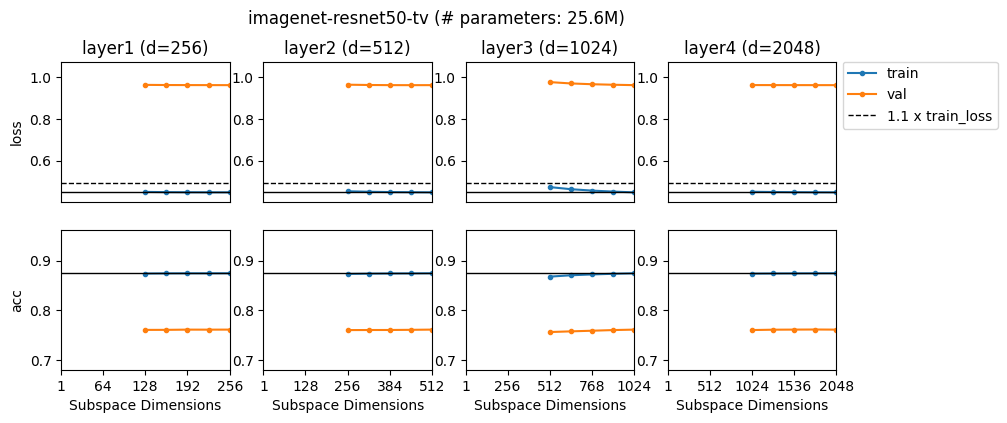

In [5]:
viz(
    model_name="imagenet-resnet50-tv",
    arr_layers=["layer1", "layer2", "layer3", "layer4"]
)

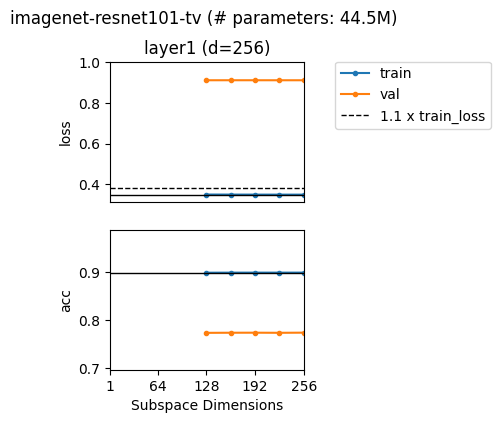

In [13]:
viz(
    model_name="imagenet-resnet101-tv",
    arr_layers=["layer1", "layer2", "layer3", "layer4"][:1]
)

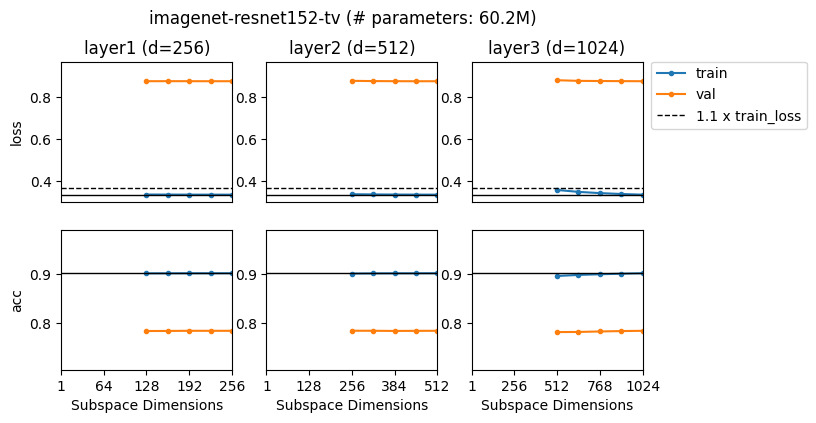

In [6]:
viz(
    model_name="imagenet-resnet152-tv",
    arr_layers=["layer1", "layer2", "layer3", "layer4"][:3]
)

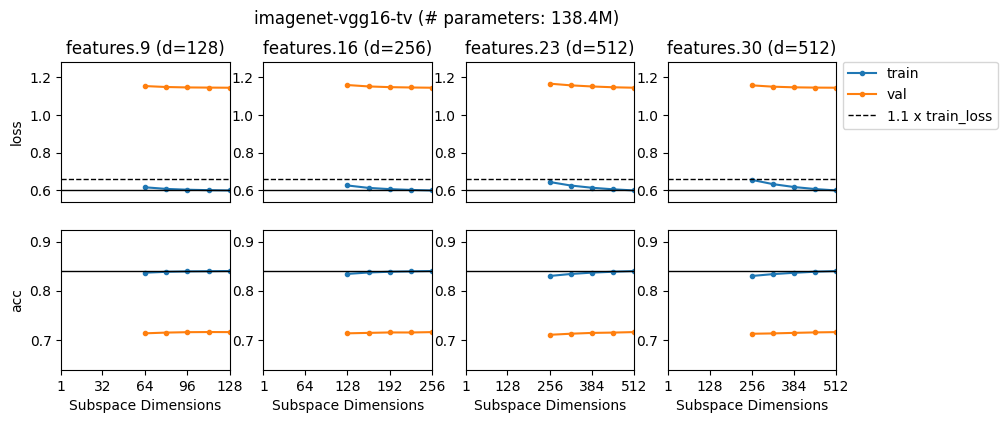

In [7]:
viz(
    model_name="imagenet-vgg16-tv",
    arr_layers=["features.9", "features.16", "features.23", "features.30"]
)

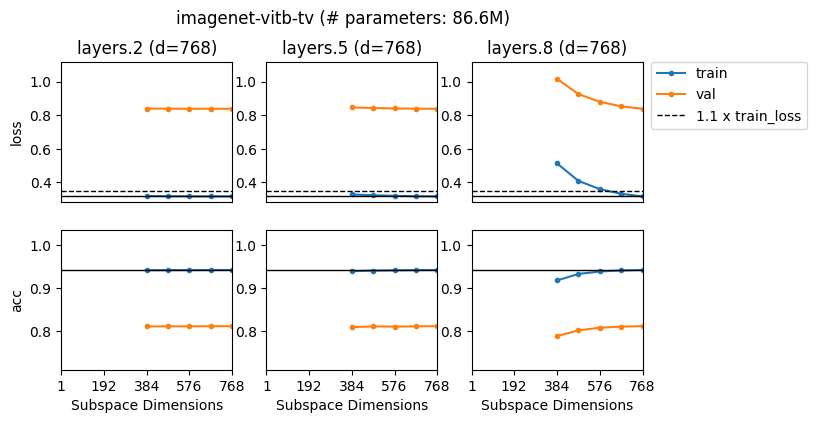

In [8]:
viz(
    model_name="imagenet-vitb-tv",
    arr_layers=["encoder.layers.2", "encoder.layers.5", "encoder.layers.8"]
)

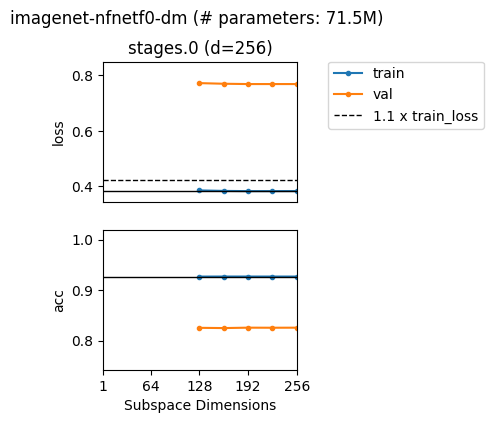

In [11]:
viz(
    model_name="imagenet-nfnetf0-dm",
    arr_layers=["stages.0", "stages.1"][:1]
)